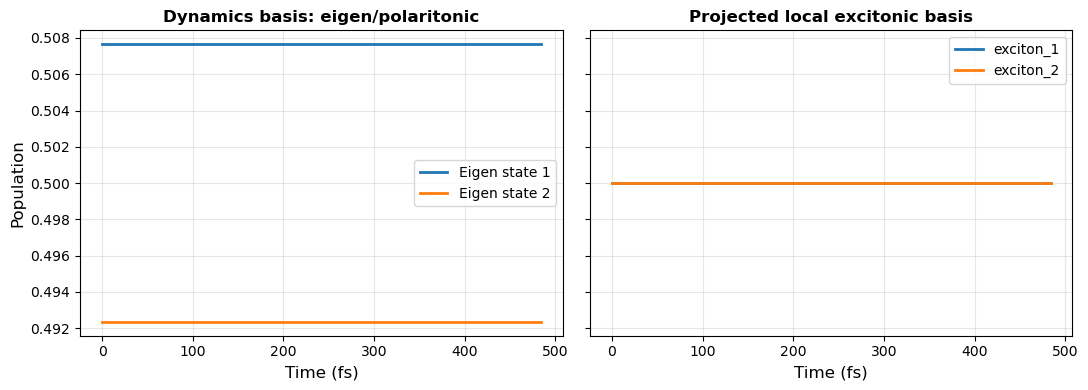

Eigen energies (eV, shifted by lowest):
  Eigen state 1: 0.00000000
  Eigen state 2: 0.02000000

Max eigen-basis populations:
  Eigen state 1: 0.507656
  Eigen state 2: 0.492344

Max projected excitonic-basis populations:
  exciton_1: 0.5
  exciton_2: 0.5

Mean eigen-basis total population: 1
Mean projected excitonic-basis total population: 1


In [2]:
#!/usr/bin/env python3
"""
Plot two-level LVC dynamics propagated in the eigen/polaritonic basis.

`pop.out` contains eigen-basis populations because lvc_parameters_mash.py passes
a diagonalized system Hamiltonian to MASH. The excitonic-basis populations are
computed by the simple population projection

    P_exciton_i(t) = sum_a |U[i, a]|^2 P_eigen_a(t)

where U[i, a] is saved in polariton_transform_AU.npz.
"""

import numpy as np
import matplotlib.pyplot as plt

autos = 2.4188843265857e-17
au_to_eV = 27.2114079527
n_states_expected = 2

data = np.loadtxt("pop.out")
time = data[:, 0] * autos * 1e15  # au to fs
eigen_pop = data[:, 1:]
n_states = eigen_pop.shape[1]

if n_states != n_states_expected:
    raise ValueError(f"Expected {n_states_expected} states, found {n_states}")

transform = np.load("polariton_transform_AU.npz", allow_pickle=True)
U = transform["exciton_to_polariton_U"]
eigen_energies_AU = transform["polariton_energies_AU"]
state_labels = transform["exciton_state_labels"] if "exciton_state_labels" in transform.files else None

if U.shape != (n_states_expected, n_states_expected):
    raise ValueError(f"Unexpected transformation matrix shape {U.shape}")

projection_weights = np.abs(U) ** 2
exciton_pop = eigen_pop @ projection_weights.T

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

ax = axes[0]
for state in range(n_states_expected):
    ax.plot(time, eigen_pop[:, state], label=f"Eigen state {state + 1}", linewidth=2)
ax.set_xlabel("Time (fs)", fontsize=12)
ax.set_ylabel("Population", fontsize=12)
ax.set_title("Dynamics basis: eigen/polaritonic", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

ax = axes[1]
for state in range(n_states_expected):
    label = str(state_labels[state]) if state_labels is not None else f"Exciton state {state + 1}"
    ax.plot(time, exciton_pop[:, state], label=label, linewidth=2)
ax.set_xlabel("Time (fs)", fontsize=12)
ax.set_title("Projected local excitonic basis", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Eigen energies (eV, shifted by lowest):")
energies_eV = (eigen_energies_AU - eigen_energies_AU.min()) * au_to_eV
for state, energy in enumerate(energies_eV):
    print(f"  Eigen state {state + 1}: {energy:.8f}")

print("\nMax eigen-basis populations:")
for state in range(n_states_expected):
    print(f"  Eigen state {state + 1}: {eigen_pop[:, state].max():.6g}")

print("\nMax projected excitonic-basis populations:")
for state in range(n_states_expected):
    label = str(state_labels[state]) if state_labels is not None else f"Exciton state {state + 1}"
    print(f"  {label}: {exciton_pop[:, state].max():.6g}")

print(f"\nMean eigen-basis total population: {eigen_pop.sum(axis=1).mean():.6g}")
print(f"Mean projected excitonic-basis total population: {exciton_pop.sum(axis=1).mean():.6g}")


In [ ]:
# Check conservation after projection from eigen to local excitonic basis.
print("eigen-basis total:", eigen_pop.sum(axis=1))
print("projected excitonic-basis total:", exciton_pop.sum(axis=1))

array([2.74563358e-17, 1.55725648e-06, 1.10449800e-05, 2.85559604e-05,
       5.41609812e-05, 8.79097987e-05, 1.29830339e-04, 1.79927655e-04,
       2.38180794e-04, 3.04548339e-04, 3.78969130e-04, 4.61360559e-04,
       5.51621203e-04, 6.49625808e-04, 7.55228497e-04, 8.68264916e-04,
       9.88551072e-04, 1.11588446e-03, 1.25004932e-03, 1.39082085e-03,
       1.53795913e-03, 1.69121581e-03, 1.85033597e-03, 2.01505890e-03,
       2.18512050e-03, 2.36025103e-03, 2.54017983e-03, 2.72463544e-03,
       2.91334857e-03, 3.10605010e-03, 3.30246969e-03, 3.50233337e-03,
       3.70537174e-03, 3.91131665e-03, 4.11989822e-03, 4.33085165e-03,
       4.54391483e-03, 4.75883290e-03, 4.97535348e-03, 5.19322568e-03,
       5.41220143e-03, 5.63203961e-03, 5.85250880e-03, 6.07338750e-03,
       6.29446816e-03, 6.51555315e-03, 6.73645334e-03, 6.95699196e-03,
       7.17700689e-03, 7.39635194e-03, 7.61489592e-03, 7.83252640e-03,
       8.04914845e-03, 8.26468362e-03, 8.47907455e-03, 8.69228189e-03,
      